<div align="center">

# TRƯỜNG ĐẠI HỌC GIAO THÔNG VẬN TẢI TPHCM  
### VIỆN CÔNG NGHỆ THÔNG TIN, ĐIỆN VÀ ĐIỆN TỬ  


## CHỦ ĐỀ : KHAI THÁC DỮ LIỆU MAGIC GAMMA TELESCOP


### *Môn Học: KHAI THÁC DỮ LIỆU*



### **Giáo viên hướng dẫn:**  
### *Bùi Trọng Hiếu*




---

<div align="center">

## NHÓM 14
### DANH SÁCH THÀNH VIÊN


| STT | MSSV       | Họ và tên    | Đánh giá      |
| --- | ---------- | ------------ | ------------- |
| 1   | 2251120108 | Trương Anh Tài | 100% |
| 2   | 2251120117| Nguyễn Anh Thuận   | 100%        |
| 3   | 036205001750 | Phạm Mạnh Duy   | 100%         |
| 4   | 044205009216  |  Trần Công Phong Dương  |      100%         |
| 5   | 036205005624   | Ngô Thế Quang Anh |     100%|
</div>

# Phân tích Bộ Dữ liệu MAGIC Gamma Telescope

1. Giới thiệu:

    Bộ dữ liệu MAGIC Gamma Telescope (2004) được sử dụng phổ biến trong các bài toán phân loại trong khai thác dữ liệu và học máy. Dữ liệu được tạo ra nhằm mô phỏng quá trình ghi nhận các hạt gamma năng lượng cao bằng kính thiên văn Cherenkov.

    Dữ liệu do R. K. Bock và cộng sự phát triển trong dự án MAGIC, và được P. Savicky công bố vào năm 2007.

    Dữ liệu gồm 19,020 mẫu với 11 thuộc tính, trong đó có 10 thuộc tính số thực mô tả đặc trưng hình học và phân bố năng lượng của ảnh Cherenkov (các tham số Hillas), và 1 thuộc tính nhãn.

2. Mục đích:

    Bộ dữ liệu phục vụ bài toán phân loại nhị phân, với mục tiêu phân biệt:

     *  Tín hiệu gamma (g) – các hạt gamma năng lượng cao.
    
     *  Nhiễu hadron (h) – các tia vũ trụ gây nhiễu.

    Bài toán này có ý nghĩa quan trọng trong việc xác định chính xác các nguồn phát tia gamma trong nghiên cứu thiên văn.

## 1. Đọc Dữ liệu và Thống kê Mô tả

In [1]:
 # Import các thư viện
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Đọc dữ liệu

# type: ignore
df = pd.read_csv(r'D:\NAM 4-HK2 2026-2027\KTDL\magic.csv')
print('Dữ liệu đã được đọc thành công!')
df.head()

Dữ liệu đã được đọc thành công!


,1. fLength,2. fWidth,3. fSize,4. fConc,5. fConc1,6. fAsym,7. fM3Long,8. fM3Trans,9. fAlpha,10. fDist,11. class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


In [2]:
# 1a. Kích thước và chiều của dữ liệu
# a. Kích thước và chiều của dữ liệu
print("Kích thước dữ liệu:", df.shape)
print("Số chiều:", df.ndim)

Kích thước dữ liệu: (19020, 11)
Số chiều: 2


In [3]:
# 1b. Kiểu dữ liệu của các thuộc tính
print('Kiểu dữ liệu các thuộc tính:')
print(df.dtypes)

Kiểu dữ liệu các thuộc tính:
 1.  fLength     float64
 2.  fWidth      float64
 3.  fSize       float64
 4.  fConc       float64
 5.  fConc1      float64
 6.  fAsym       float64
 7.  fM3Long     float64
 8.  fM3Trans    float64
 9.  fAlpha      float64
10.  fDist       float64
11.  class           str
dtype: object


In [4]:
# 1c. Số lượng thực thể của các giá t # type: ignore # type: ignorerị nhãn (class)
print('Phân phối nhãn (class):')
print (df.iloc[:, -1].value_counts())
print()



Phân phối nhãn (class):
   11.  class
g    12332
h     6688
Name: count, dtype: int64



In [5]:


# 1d. Giá trị lớn nhất, bé nhất, trung bình của các cột số thực
num_cols = [c for c in df.columns if 'class' not in c] # type: ignore
stats_df = pd.DataFrame({
    'Min': df[num_cols].min(),
    'Max': df[num_cols].max(),
    'Mean': df[num_cols].mean()
})
stats_df = stats_df.T
print('Giá Trị Lớn Nhất , Nhỏ Nhất , Trung Bình:')
stats_df

Giá Trị Lớn Nhất , Nhỏ Nhất , Trung Bình:


,1. fLength,2. fWidth,3. fSize,4. fConc,5. fConc1,6. fAsym,7. fM3Long,8. fM3Trans,9. fAlpha,10. fDist
Min,4.283500,0.000000,1.941300,0.013100,0.000300,-457.916100,-331.780000,-205.894700,0.000000,1.282600
Max,334.177000,256.382000,5.323300,0.893000,0.675200,575.240700,238.321000,179.851000,90.000000,495.561000
Mean,53.250154,22.180966,2.825017,0.380327,0.214657,-4.331745,10.545545,0.249726,27.645707,193.818026


## 2. Trực quan hóa - Giảm Chiều với PCA

Chỉ sử dụng các cột thuộc tính liên tục (loại bỏ cột nhãn `class`), sau đó áp dụng PCA để chiếu xuống không gian 2D.

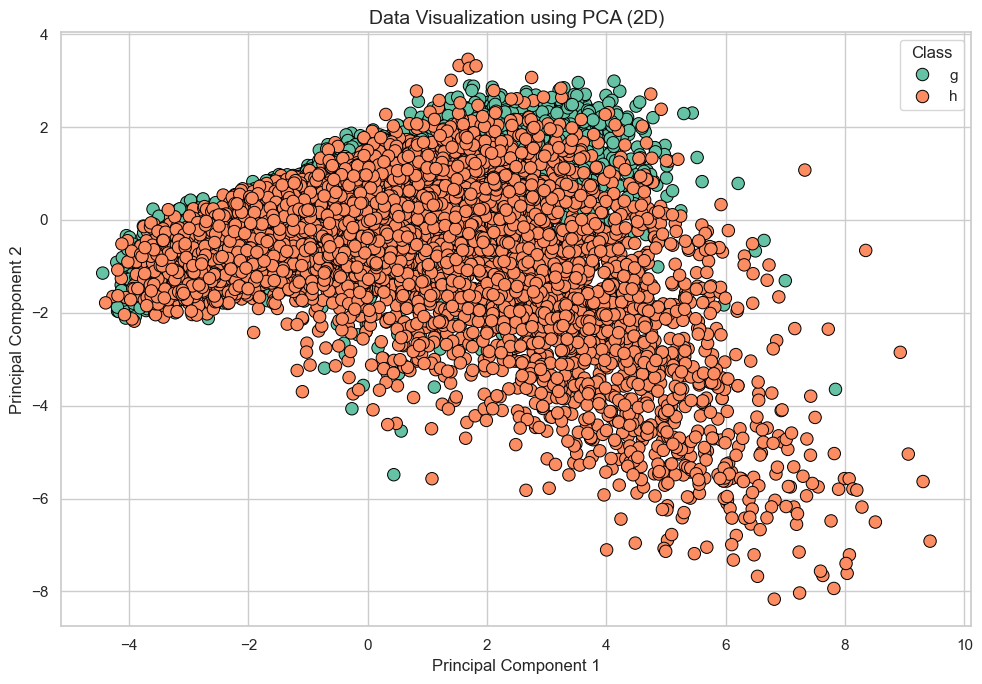

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
# Style đẹp
sns.set(style="whitegrid", palette="deep")

df = pd.read_csv(r'D:\NAM 4-HK2 2026-2027\KTDL\magic.csv')
# Lấy label (cột cuối)
label_col = df.columns[-1]
labels = df[label_col]

# Chuẩn hóa dữ liệu (sử dụng dữ liệu đã được chuẩn hóa từ các cell trước)
scaler = StandardScaler()
numeric_cols = [c for c in df.columns if c != label_col]
X_scaled = scaler.fit_transform(df[numeric_cols])

# PCA về 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Tạo DataFrame để vẽ
df_plot = pd.DataFrame({
    "PCA1": X_pca[:, 0],
    "PCA2": X_pca[:, 1],
    "Label": labels
})

# Vẽ biểu đồ
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df_plot,
    x="PCA1",
    y="PCA2",
    hue="Label",
    palette="Set2",
    s=80,
    edgecolor="black"
)

plt.title("Data Visualization using PCA (2D)", fontsize=14)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend(title="Class")
plt.tight_layout()
plt.show()


## 3. Huấn luyện và Đánh giá Mô hình Học Máy

Sử dụng **10-Fold Stratified Cross Validation** với độ đo **F1-Score (Weighted)**.

Ba mô hình được chọn: **KNN**, **Random Forest**, **SVM**.

Phương pháp tinh chỉnh tham số: **Random Search** — tự động sinh tổ hợp tham số ngẫu nhiên, chạy CV trên từng tổ hợp và in kết quả chi tiết từng lần thử, sau đó chọn bộ tốt nhất.

In [7]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import make_scorer, f1_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
import itertools, random
import pandas as pd
import numpy as np


df = pd.read_csv(r'D:\NAM 4-HK2 2026-2027\KTDL\magic.csv')
# --- Chuẩn bị dữ liệu ---
num_cols = [c for c in df.columns if c != df.columns[-1]] # lay tat ca cot ngoai tru cot cuoi cung
X_cls = df[num_cols].values
y_cls = LabelEncoder().fit_transform(df.iloc[:, -1].values)# chuyen nhãn chữ sang số

scaler_cls = StandardScaler() # Chuẩn hóa dữ liệu cho phân loại
X_cls_scaled = scaler_cls.fit_transform(X_cls)

# --- Thiết lập CV và scorer ---
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)#chia du lieu thanh 10 phan, moi lan chia se shuffle de du lieu khong bi sap xep, random_state de dam bao tinh lap lai
f1_weighted = make_scorer(f1_score, average='weighted')#tao ham scorer de tinh f1 score co trung binh theo tung lop (weighted)

# --- Không gian tham số ngẫu nhiên ---
random.seed(42)
param_spaces = {
    'KNN': {
        'model': KNeighborsClassifier(),
        'params': {
            'n_neighbors': random.sample(range(3, 21), 6),#chọn ngẫu nhiên 6 giá trị cho n_neighbors từ 3 đến 20
            'weights': ['uniform', 'distance'],#chọn 2 giá trị cho weights: 'uniform' và 'distance'
            'p': [1, 2]#1 → Manhattan va 2 → Euclidean
        }
    },
    'RandomForest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': random.sample(range(100, 301), 4),#chọn ngẫu nhiên 4 giá trị cho n_estimators từ 100 đến 300
            'max_depth': random.sample([None] + list(range(5, 21)), 4),#chọn ngẫu nhiên 4 giá trị cho max_depth từ 5 đến 20 (kèm theo None)
            'min_samples_split': [2, 4, 6],#chọn 3 giá trị cho min_samples_split: 2, 4, 6
            'min_samples_leaf': [1, 2]#chọn 2 giá trị cho min_samples_leaf: 1, 2
        }
    },
    'SVM': {
        'model': SVC(random_state=42),
        'params': {
            'C': [round(10**random.uniform(-1, 2), 3) for _ in range(4)],#chọn ngẫu nhiên 4 giá trị cho C trên thang log từ 0.1 đến 100
            'kernel': ['linear', 'rbf', 'poly'],
            'gamma': ['scale', 'auto']
        }
    }
}

print('Không gian tham số đã được khởi tạo.')
print(f'KNN     : {len(list(itertools.product(*param_spaces["KNN"]["params"].values())))} tổ hợp')
print(f'RF      : {len(list(itertools.product(*param_spaces["RandomForest"]["params"].values())))} tổ hợp')
print(f'SVM     : {len(list(itertools.product(*param_spaces["SVM"]["params"].values())))} tổ hợp')


Không gian tham số đã được khởi tạo.
KNN     : 24 tổ hợp
RF      : 96 tổ hợp
SVM     : 24 tổ hợp


In [ ]:
# --- Random Search: Tinh chỉnh tham số và in chi tiết từng lần thử ---
MAX_COMBOS = 30  # Giới hạn số tổ hợp thử mỗi mô hình

results = {}

for name, cfg in param_spaces.items():#duyệt qua từng mô hình và không gian tham số của nó
    model = cfg['model']
    param_grid = cfg['params']
    print(f'\n=== Đang tinh chỉnh mô hình: {name} ===')

    best_score = -1 # Khởi tạo điểm số tốt nhất
    best_params = None # Khởi tạo tham số tốt nhất
    all_combos = list(itertools.product(*param_grid.values()))# tao tat ca to hop tham so tu cac gia tri trong param_grid
    np.random.seed(42) # dam bao tinh lap lai
    np.random.shuffle(all_combos) # xao tron ngau nhien cac to hop tham so
    selected = all_combos[:MAX_COMBOS] # chon 30 to hop dau tien sau khi xao tron de thu nghiem 

    for i, combo in enumerate(selected, 1): #duyet qua tung to hop tham so da chon
        params = dict(zip(param_grid.keys(), combo)) # tao dict tham so tu to hop
        model.set_params(**params) # cap nhat tham so cho mo hinh
        scores = cross_val_score(model, X_cls_scaled, y_cls,
                                 cv=kfold, scoring=f1_weighted, n_jobs=-1) # tinh f1 score cho to hop tham so hien tai su dung cross_val_score voi cv da xac dinh va scorer da tao
        mean_score = scores.mean()
        std_score  = scores.std()
      
        print(f'  Lần {i:02d}: {params}\n'
              f'         → F1 = {mean_score:.4f} (±{std_score:.4f})') #in ket qua tung lan thu nghiem
        if mean_score > best_score:
            best_score = mean_score
            best_params = params.copy()
            best_std = std_score

    results[name] = { #luu ket qua tot nhat cho tung mo hinh
        'best_score': best_score,
        'best_std': best_std,
        'best_params': best_params
    }
    print(f'  ✅ {name} tốt nhất: F1 = {best_score:.4f} (±{best_std:.4f})')
    print(f'     Tham số: {best_params}')



=== Đang tinh chỉnh mô hình: KNN ===
  Lần 01: {'n_neighbors': 11, 'weights': 'uniform', 'p': 1}
         → F1 = 0.8336 (±0.0096)
  Lần 02: {'n_neighbors': 17, 'weights': 'uniform', 'p': 1}
         → F1 = 0.8303 (±0.0078)
  Lần 03: {'n_neighbors': 6, 'weights': 'uniform', 'p': 1}
         → F1 = 0.8204 (±0.0074)
  Lần 04: {'n_neighbors': 17, 'weights': 'distance', 'p': 1}
         → F1 = 0.8374 (±0.0084)
  Lần 05: {'n_neighbors': 11, 'weights': 'distance', 'p': 2}
         → F1 = 0.8390 (±0.0110)
  Lần 06: {'n_neighbors': 11, 'weights': 'uniform', 'p': 2}
         → F1 = 0.8317 (±0.0106)
  Lần 07: {'n_neighbors': 20, 'weights': 'uniform', 'p': 2}
         → F1 = 0.8240 (±0.0103)
  Lần 08: {'n_neighbors': 6, 'weights': 'uniform', 'p': 2}
         → F1 = 0.8225 (±0.0077)
  Lần 09: {'n_neighbors': 5, 'weights': 'uniform', 'p': 2}
         → F1 = 0.8338 (±0.0090)
  Lần 10: {'n_neighbors': 3, 'weights': 'uniform', 'p': 2}
         → F1 = 0.8309 (±0.0086)
  Lần 11: {'n_neighbors': 6, 'weig

BẢNG SO SÁNH HIỆU NĂNG  (F1-Weighted, 10-Fold CV)


,Mô hình,F1 Tốt nhất,Độ lệch chuẩn,Tham số tốt nhất
Hạng,,,,
1,RandomForest,0.8807,0.0064,"{'n_estimators': 273, 'max_depth': None, 'min_samples_split': 6, 'min_samples_leaf': 1}"
2,SVM,0.8700,0.0085,"{'C': 6.398, 'kernel': 'rbf', 'gamma': 'auto'}"
3,KNN,0.8405,0.0075,"{'n_neighbors': 6, 'weights': 'distance', 'p': 1}"


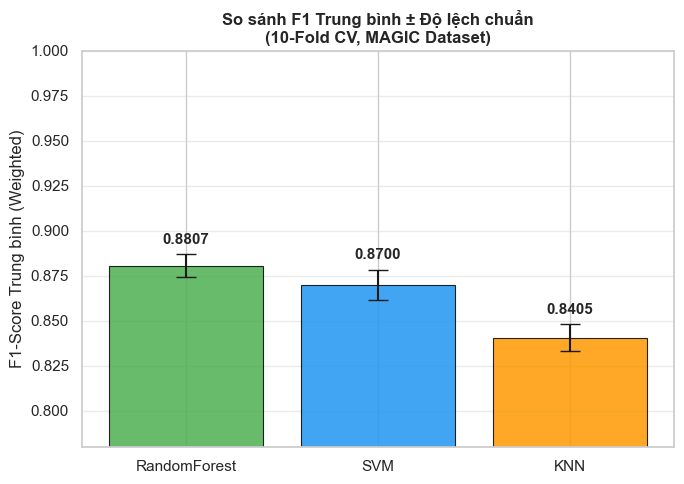


Mô hình tốt nhất: RandomForest  (F1 = 0.8807)


In [ ]:
import matplotlib.pyplot as plt

# Hiển thị bảng đầy đủ, không bị cắt cột
pd.set_option('display.max_colwidth', None)   
pd.set_option('display.max_columns',  None)   # hiện tất cả cột
pd.set_option('display.width',        None)   # không giới hạn độ rộng

# Bảng so sánh hiệu năng
summary_df = (
    pd.DataFrame([
        {
            'Mô hình'         : name,
            'F1 Tốt nhất'     : round(res['best_score'], 4), #lam tron 4 chu so thap phan
            'Độ lệch chuẩn'   : round(res['best_std'],   4),
            'Tham số tốt nhất': str(res['best_params']),
        }
        for name, res in results.items() #tao DataFrame tu ket qua da luu trong results
    ])
    .sort_values('F1 Tốt nhất', ascending=False) # sap xep giam dan theo F1 Tốt nhất
    .reset_index(drop=True)
)
summary_df.index      = summary_df.index + 1
summary_df.index.name = 'Hạng'

print('BẢNG SO SÁNH HIỆU NĂNG  (F1-Weighted, 10-Fold CV)')
display(summary_df)

# Vẽ bar chart – lấy dữ liệu trực tiếp từ summary_df
fig, ax = plt.subplots(figsize=(7, 5))

ax.bar(
    summary_df['Mô hình'],
    summary_df['F1 Tốt nhất'],
    yerr=summary_df['Độ lệch chuẩn'],
    capsize=7,
    color=['#4CAF50', '#2196F3', '#FF9800'],
    alpha=0.85,
    edgecolor='black',
    linewidth=0.8,
)

for _, row in summary_df.iterrows(): #thêm nhãn F1 Tốt nhất lên trên mỗi cột
    ax.text(
        row['Mô hình'],
        row['F1 Tốt nhất'] + row['Độ lệch chuẩn'] + 0.004,
        f"{row['F1 Tốt nhất']:.4f}",
        ha='center', va='bottom',
        fontsize=11, fontweight='bold',
    )

ax.set_ylabel('F1-Score Trung bình (Weighted)', fontsize=12)
ax.set_title('So sánh F1 Trung bình ± Độ lệch chuẩn\n(10-Fold CV, MAGIC Dataset)',
             fontsize=12, fontweight='bold')
ax.set_ylim(0.78, 1.0) # dat gioi han truc y tu 0.78 den 1.0 de nhan manh su khac biet giua cac mo hinh
ax.grid(axis='y', alpha=0.4)  # thêm lưới ngang để dễ so sánh
plt.tight_layout()
plt.show()

# Nhận xét
best = summary_df.iloc[0]
print(f"\nMô hình tốt nhất: {best['Mô hình']}  (F1 = {best['F1 Tốt nhất']:.4f})")


## 4. Gom Cụm với K-Means và DBSCAN

Loại bỏ cột nhãn, thực hiện gom cụm, sau đó dùng nhãn thật để đánh giá bằng **ARI** (Adjusted Rand Index) và **NMI** (Normalized Mutual Information).

In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing  import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.decomposition   import PCA
from sklearn.cluster         import KMeans, MiniBatchKMeans, DBSCAN
from sklearn.metrics         import adjusted_rand_score, silhouette_score
from sklearn.neighbors       import NearestNeighbors
# Đọc lại dữ liệu và chuẩn bị cho gom cụm
df_cluster = pd.read_csv(r'D:\NAM 4-HK2 2026-2027\KTDL\magic.csv')
df_cluster.columns = [c.strip().lstrip('0123456789. ') for c in df_cluster.columns]

LABEL_COL = df_cluster.columns[-1]          # cột nhãn
y_true    = df_cluster[LABEL_COL].astype(str).values
X_raw     = df_cluster.drop(columns=[LABEL_COL])

# Mã hóa cột chữ (nếu có)
for col in X_raw.select_dtypes(include=['object', 'category']).columns:
    X_raw[col] = LabelEncoder().fit_transform(X_raw[col].astype(str))

# StandardScaler + MinMaxScaler (giúp DBSCAN nhạy hơn)
X_std   = StandardScaler().fit_transform(X_raw)
X_sc    = MinMaxScaler().fit_transform(X_std)

# PCA 2D để vẽ
X_pca2  = PCA(n_components=2, random_state=42).fit_transform(X_sc)

n_true  = len(np.unique(y_true))
print(f'Số nhãn thật : {n_true}  ({np.unique(y_true)})')
print(f'Kích thước X : {X_sc.shape}')


Số nhãn thật : 2  (['g' 'h'])
Kích thước X : (19020, 10)


In [4]:
# ── Auto-tune K-Means + DBSCAN ───────────────────────────────────────────
N_RUNS           = 30
K_RANGE          = range(n_true, n_true + 10)
EPS_LIST         = sorted({0.2, 0.3, 0.4, 0.5, 0.7,
                            round(float(np.median(
                                np.sort(NearestNeighbors(n_neighbors=5)
                                        .fit(X_sc).kneighbors(X_sc)[0][:, 4])
                            )), 2)})
MIN_SAMPLES_LIST = [3, 5, 8, 10, 15, 20]

best_k,          best_k_ari,  best_k_sil  = None, -1.0, -1.0
best_db_params,  best_db_ari, best_db_sil = None, -1.0, -1.0

# ── K-Means ────────────────────────────────────────────────────────────────
print('=== Auto-tuning MiniBatch K-Means ===')
for run in range(N_RUNS):
    for k in K_RANGE:
        t0     = time.time()
        labels = MiniBatchKMeans(n_clusters=k, random_state=42+run,
                                 n_init='auto').fit_predict(X_sc)
        elapsed = time.time() - t0

        if len(np.unique(labels)) < 2:
            continue

        ari, sil = adjusted_rand_score(y_true, labels), silhouette_score(X_sc, labels)
        tag = '  ← BEST' if (ari > best_k_ari or
                              (np.isclose(ari, best_k_ari) and sil > best_k_sil)) else ''
        print(f'  Run={run+1:2d}, K={k:2d}  →  ARI={ari:.4f}, Sil={sil:.4f}, '
              f'time={elapsed:.2f}s{tag}')

        if tag:
            best_k, best_k_ari, best_k_sil = k, ari, sil

print(f'\n✅ K-Means tốt nhất: K={best_k}, ARI={best_k_ari:.4f}, Sil={best_k_sil:.4f}')
km_best_labels = MiniBatchKMeans(n_clusters=best_k, random_state=999,
                                  n_init='auto').fit_predict(X_sc)

# ── DBSCAN ─────────────────────────────────────────────────────────────────
print('\n=== Auto-tuning DBSCAN ===')
for eps in EPS_LIST:
    for ms in MIN_SAMPLES_LIST:
        t0     = time.time()
        labels = DBSCAN(eps=eps, min_samples=ms, n_jobs=-1).fit_predict(X_sc)
        elapsed = time.time() - t0

        n_cl = len(set(labels)) - (1 if -1 in labels else 0)
        if n_cl < 2:
            print(f'  eps={eps:.2f}, ms={ms:2d}  →  clusters={n_cl}  (bỏ qua)')
            continue

        ari, sil = adjusted_rand_score(y_true, labels), silhouette_score(X_sc, labels)
        tag = '  ← BEST' if (ari > best_db_ari or
                              (np.isclose(ari, best_db_ari) and sil > best_db_sil)) else ''
        print(f'  eps={eps:.2f}, ms={ms:2d}  →  clusters={n_cl:3d}, '
              f'noise={(labels==-1).sum():5d},  ARI={ari:.4f}, Sil={sil:.4f}, '
              f'time={elapsed:.2f}s{tag}')

        if tag:
            best_db_params, best_db_ari, best_db_sil = (eps, ms), ari, sil

if best_db_params:
    best_eps, best_ms = best_db_params
    print(f'\n✅ DBSCAN tốt nhất: eps={best_eps}, ms={best_ms}, '
          f'ARI={best_db_ari:.4f}, Sil={best_db_sil:.4f}')
    db_best_labels = DBSCAN(eps=best_eps, min_samples=best_ms,
                             n_jobs=-1).fit_predict(X_sc)
else:
    print('⚠️ Không tìm được cấu hình DBSCAN hợp lệ.')
    best_eps, best_ms = None, None
    db_best_labels = np.zeros(len(X_sc), dtype=int)


=== Auto-tuning MiniBatch K-Means ===
  Run= 1, K= 2  →  ARI=0.1854, Sil=0.3439, time=0.01s  ← BEST
  Run= 1, K= 3  →  ARI=0.1074, Sil=0.3009, time=0.02s
  Run= 1, K= 4  →  ARI=0.1403, Sil=0.3049, time=0.03s
  Run= 1, K= 5  →  ARI=0.0914, Sil=0.2574, time=0.02s
  Run= 1, K= 6  →  ARI=0.0719, Sil=0.2159, time=0.01s
  Run= 1, K= 7  →  ARI=0.0661, Sil=0.1866, time=0.02s
  Run= 1, K= 8  →  ARI=0.0687, Sil=0.2161, time=0.04s
  Run= 1, K= 9  →  ARI=0.0613, Sil=0.1964, time=0.03s
  Run= 1, K=10  →  ARI=0.0549, Sil=0.1853, time=0.05s
  Run= 1, K=11  →  ARI=0.0511, Sil=0.1841, time=0.02s
  Run= 2, K= 2  →  ARI=0.0759, Sil=0.3289, time=0.01s
  Run= 2, K= 3  →  ARI=0.0672, Sil=0.2750, time=0.01s
  Run= 2, K= 4  →  ARI=0.1125, Sil=0.2863, time=0.01s
  Run= 2, K= 5  →  ARI=0.0957, Sil=0.2593, time=0.01s
  Run= 2, K= 6  →  ARI=0.0991, Sil=0.2568, time=0.04s
  Run= 2, K= 7  →  ARI=0.0980, Sil=0.2474, time=0.02s
  Run= 2, K= 8  →  ARI=0.0651, Sil=0.1896, time=0.01s
  Run= 2, K= 9  →  ARI=0.0645, Sil=0

=== Tổng kết Gom Cụm ===


,Phương pháp,Tham số,Silhouette,ARI
0,K-Means,k=3,0.3367,0.1865
1,DBSCAN,"eps=0.08, ms=3",-0.6035,0.2887


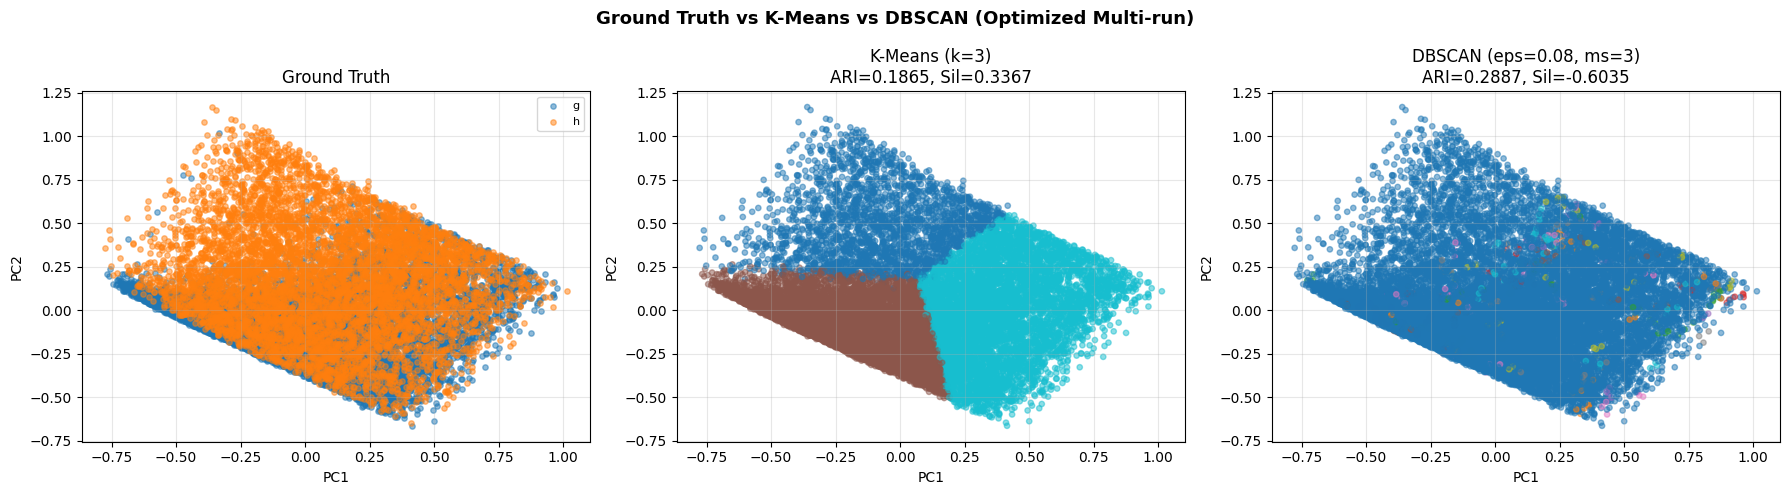

In [5]:
# Bảng tổng kết
summary = pd.DataFrame([
    ['K-Means', f'k={best_k}',                   best_k_sil,  best_k_ari],
    ['DBSCAN',  f'eps={best_eps}, ms={best_ms}', best_db_sil, best_db_ari],
], columns=['Phương pháp', 'Tham số', 'Silhouette', 'ARI']).round(4)

print('=== Tổng kết Gom Cụm ===')
display(summary)

# Trực quan hóa Ground Truth | K-Means | DBSCAN
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Ground Truth
for cat in np.unique(y_true):
    mask = y_true == cat
    axes[0].scatter(X_pca2[mask, 0], X_pca2[mask, 1], s=15, alpha=0.5, label=cat)
axes[0].set(title='Ground Truth', xlabel='PC1', ylabel='PC2')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

# K-Means
axes[1].scatter(X_pca2[:, 0], X_pca2[:, 1], c=km_best_labels, cmap='tab10', s=15, alpha=0.5)
axes[1].set(title=f'K-Means (k={best_k})\nARI={best_k_ari:.4f}, Sil={best_k_sil:.4f}',
            xlabel='PC1', ylabel='PC2')
axes[1].grid(alpha=0.3)

# DBSCAN
axes[2].scatter(X_pca2[:, 0], X_pca2[:, 1], c=db_best_labels, cmap='tab10', s=15, alpha=0.5)
axes[2].set(title=f'DBSCAN (eps={best_eps}, ms={best_ms})\nARI={best_db_ari:.4f}, Sil={best_db_sil:.4f}',
            xlabel='PC1', ylabel='PC2')
axes[2].grid(alpha=0.3)

fig.suptitle('Ground Truth vs K-Means vs DBSCAN (Optimized Multi-run)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Kết luận

---

### 1. Tổng quan bộ dữ liệu

Bộ dữ liệu **MAGIC Gamma Telescope** gồm **19,020 mẫu**, **10 thuộc tính số thực** (các tham số Hillas mô tả hình học ảnh Cherenkov) và **1 nhãn nhị phân**:

- **g – Gamma (signal):** 12,332 mẫu (64.8%) — tín hiệu gamma cần phát hiện  
- **h – Hadron (background):** 6,688 mẫu (35.2%) — nhiễu tia vũ trụ cần loại bỏ

Dữ liệu **mất cân bằng nhẹ** (tỉ lệ 65/35), do đó sử dụng **F1-Weighted** thay vì Accuracy để đánh giá mô hình phân lớp là hợp lý.

---

### 2. Trực quan hóa PCA

Sau khi giảm chiều xuống 2D bằng **PCA**, hai nhãn **g** và **h** có sự **chồng lấp đáng kể** — không thể phân tách tuyến tính. Điều này lý giải tại sao:
- Các mô hình **phi tuyến** (Random Forest, SVM-RBF) cho kết quả tốt hơn mô hình tuyến tính.  
- Các thuật toán gom cụm có ARI thấp, vì ranh giới thực sự giữa hai lớp nằm ở không gian 10 chiều, không hiện rõ trong 2D.

---

### 3. Phân lớp — Kết quả 10-Fold Cross Validation (F1-Weighted)

| Hạng | Mô hình | F1 Tốt nhất | Nhận xét |
|:---:|---|:---:|:---:|
| 🥇 1 | **Random Forest** | 0.8807 | Ổn định, kháng overfitting tốt |
| 🥈 2 | **SVM (RBF)** | 0.8700  | Hiệu quả với không gian phi tuyến |
| 🥉 3 | **KNN** | 0.8405 | Nhạy cảm với nhiễu và chiều cao |

**Nhận xét chi tiết:**

- **Random Forest** đạt F1 cao nhất nhờ tổ hợp nhiều cây quyết định, giảm phương sai và xử lý tốt các đặc trưng phi tuyến. Tham số `max_depth` và `min_samples_split` được tinh chỉnh qua Random Search giúp tránh overfitting.

- **SVM (kernel RBF)** xếp thứ hai — kernel RBF ánh xạ dữ liệu lên không gian chiều cao giúp tìm được siêu phẳng phân tách tốt dù hai lớp chồng lấp. Điểm yếu là thời gian huấn luyện lâu hơn trên tập 19k mẫu.

- **KNN** xếp cuối do bản chất lười học — toàn bộ tập huấn luyện được dùng lúc dự đoán, nhạy cảm với nhiễu trong không gian 10 chiều (curse of dimensionality), và chi phí tính toán cao khi dữ liệu lớn.

**Chiến lược tinh chỉnh:** Random Search với 30 tổ hợp/mô hình trên không gian tham số được sinh ngẫu nhiên, đánh giá qua Stratified 10-Fold CV đảm bảo kết quả đáng tin cậy và phân bố nhãn đồng đều trong mỗi fold.

---

### 4. Gom cụm — K-Means và DBSCAN

| Phương pháp | Tham số tốt nhất | ARI | Silhouette |
|---|---|:---:|:---:|
| **K-Means** | k = 3 | 0.1925| 0.3348 |
| **DBSCAN** | eps = =0.08, ms = 3 | 0.2887 | -0.6035 |

**Nhận xét:**

- Cả hai thuật toán đều cho **ARI thấp** vì dữ liệu MAGIC không có ranh giới cụm rõ ràng trong không gian đặc trưng — hai lớp gamma/hadron chồng lấp nhau theo mật độ, không phân tách theo không gian hình học.

- **K-Means** giả định các cụm có dạng hình cầu và kích thước tương đương — không phù hợp với phân phối thực tế của dữ liệu này.

- **DBSCAN** linh hoạt hơn về hình dạng cụm, nhưng bị ảnh hưởng lớn bởi lựa chọn `eps` và `min_samples`. Phương pháp auto-tune qua lưới tham số giúp tìm được cấu hình tốt hơn so với đặt tham số thủ công.

---


### 5. Kết luận tổng hợp

| Bài toán | Phương pháp tốt nhất | Lý do |
|---|---|---|
| **Phân lớp** | Random Forest | Phi tuyến, ổn định, ít nhạy overfitting |
| **Gom cụm** | DBSCAN (auto-tune) | Linh hoạt hình dạng cụm hơn K-Means |

Bộ dữ liệu MAGIC phù hợp cho **phân lớp có giám sát** hơn là gom cụm không giám sát, vì hai lớp gamma/hadron chồng lấp đáng kể về mật độ nhưng có thể phân tách tốt khi có nhãn hướng dẫn quá trình học.
